# ANALYSE DE FICHIERS VOLUMINEUX 


In [6]:
Data_Path = "C:\\Users\\dgr\\Documents\\data\\"

## 1/ Créer un fichier adapté (memory mapped file)

In [7]:
import vaex as vx
# un fichier trop gros va etre convertit directement en format HDF5 (format adapté aux grosses vol)
df = vx.from_csv(Data_Path+'bigfile25M.csv', convert=True, chunk_size=5_000_000)

In [8]:
import os
os.getcwd()

'C:\\Users\\dgr\\OneDrive - Publicis Groupe\\Documents\\Formations\\SCU Python\\NEW\\pgm avance\\demo'

## 2/ Analyse de fichier memory mapped avec VAEX

In [9]:
#%%timeit
# ouvrir le fichier; c'est un  memory mapped file, vaex ne lit que ses méta données

df = vx.open(Data_Path+"bigfile25M.csv.hdf5")

In [10]:
df.count()

array(25000000, dtype=int64)

In [11]:
%%timeit
# Utiliser la fonction describe ,All of these stats are computed with a single pass over the data.
df.describe()

2.13 s ± 122 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [12]:
# Lorsqu'on filtre, les données ne sont pas modifiées et cela ne créer pas de copie
# les données restent sur disque et sont processés lorsque nécessaire

df1=df[df['z']==0]

In [ ]:
# ce qui est intéressant, c'est que le filtrage ne génère pas de copie,  
# Seulement une référence à la data originale est créée avec un masque pour l'appliquer le filtrage


In [13]:
# les calculs sont out of core, la limite est la taille du disque
# filtres?
len(df1)

12496700

In [14]:
# examinnons la distribution de passenger count
df1.z.value_counts(progress=True).sort_index()

[##--------------------------------------] 100.00% elapsed time  :     0.08s =  0.0m =  0.0h
 

0    12496700
dtype: int64

In [16]:
# quand on crée une colonne, on enregistre sa définition, sera évalué lorsque nécessaire
# on lance le calcul quand on a besoin (lazy)
df1['x2']=df1['x']**2


In [18]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure()


<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

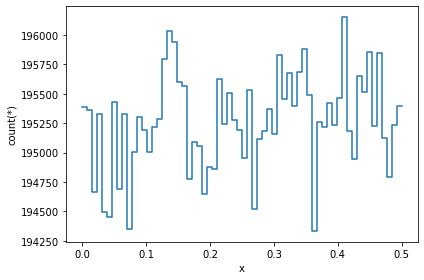

In [19]:
df1.plot1d(df1.x)

In [20]:
df1.dtypes

Unnamed: 0      int64
x             float64
y             float64
z               int64
x2            float64
dtype: object